<a href="https://colab.research.google.com/github/Ishini01/garment_defect_system/blob/main/Color_Imbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup and Mount Drive

In [1]:
# STEP 1: Setup and Mount Google Drive

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau,
    CSVLogger
)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("COLOR IMBALANCE DETECTION - COMPLETE TRAINING")
print("="*70)

Mounted at /content/drive
COLOR IMBALANCE DETECTION - COMPLETE TRAINING


Configuration

In [2]:
# STEP 2: Configuration

DATASET_PATH = '/content/drive/MyDrive/Garment_Defect_Dataset/raw_images/ColorImbalance/Images'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 30
TEST_SIZE = 0.2
VAL_SIZE = 0.1

print(f"Dataset path: {DATASET_PATH}")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Test size: {TEST_SIZE}")
print(f"Validation size: {VAL_SIZE}")

Dataset path: /content/drive/MyDrive/Garment_Defect_Dataset/raw_images/ColorImbalance/Images
Image size: (224, 224)
Batch size: 16
Epochs: 30
Test size: 0.2
Validation size: 0.1


Load Dataset

In [3]:
# STEP 3: Load Dataset

def load_images_from_folder(folder_path, label=None, img_size=(224, 224)):
    """Load images from a folder"""
    images = []
    labels = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.JPG', '.JPEG', '.PNG')

    if not os.path.exists(folder_path):
        print(f"Warning: Folder not found: {folder_path}")
        return images, labels

    files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
    print(f"Loading {len(files)} images from {os.path.basename(folder_path)}")

    for filename in files:
        img_path = os.path.join(folder_path, filename)
        try:
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img, img_size)
            img_normalized = img_resized.astype(np.float32) / 255.0
            images.append(img_normalized)
            labels.append(label)
        except Exception as e:
            print(f"Error loading {filename}: {e}")

    return images, labels

def load_dataset(base_path, img_size=(224, 224)):
    """Load dataset from folder structure"""
    all_images = []
    all_labels = []

    has_subfolders = False
    for item in os.listdir(base_path):
        if os.path.isdir(os.path.join(base_path, item)):
            has_subfolders = True
            break

    if has_subfolders:
        print("Loading from subfolders...")
        for folder in os.listdir(base_path):
            folder_path = os.path.join(base_path, folder)
            if os.path.isdir(folder_path):
                folder_lower = folder.lower()
                if any(x in folder_lower for x in ['balanced', 'good', 'normal']):
                    label = 0
                    print(f"  {folder} -> Balanced")
                elif any(x in folder_lower for x in ['imbalanced', 'defective', 'bad']):
                    label = 1
                    print(f"  {folder} -> Imbalanced")
                else:
                    print(f"  Skipping unknown folder: {folder}")
                    continue

                images, labels = load_images_from_folder(folder_path, label, img_size)
                all_images.extend(images)
                all_labels.extend(labels)
    else:
        print("Loading all images as imbalanced (label=1)")
        images, labels = load_images_from_folder(base_path, 1, img_size)
        all_images.extend(images)
        all_labels.extend(labels)

    print(f"\nTotal images loaded: {len(all_images)}")
    if len(all_images) > 0:
        unique, counts = np.unique(all_labels, return_counts=True)
        print("Class distribution:")
        for u, c in zip(unique, counts):
            class_name = "Balanced" if u == 0 else "Imbalanced"
            print(f"  {class_name}: {c} images")

    return np.array(all_images), np.array(all_labels)

print("\n[1/10] Loading dataset...")
images, labels = load_dataset(DATASET_PATH)

if len(images) == 0:
    print("\nERROR: No images found. Please check your dataset path.")
    raise SystemExit("No images loaded.")


[1/10] Loading dataset...
Loading all images as imbalanced (label=1)
Loading 490 images from Images

Total images loaded: 490
Class distribution:
  Imbalanced: 490 images


Split Dataset

In [4]:
# STEP 4: Split Dataset

print("\n[2/10] Splitting dataset...")

X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels,
    test_size=(TEST_SIZE + VAL_SIZE),
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=(TEST_SIZE / (TEST_SIZE + VAL_SIZE)),
    random_state=42,
    stratify=y_temp
)

print(f"Train: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

print("\nTrain class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {'Balanced' if u==0 else 'Imbalanced'}: {c} ({c/len(y_train)*100:.1f}%)")

print("\nTest class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {'Balanced' if u==0 else 'Imbalanced'}: {c} ({c/len(y_test)*100:.1f}%)")


[2/10] Splitting dataset...
Train: 342 samples
Validation: 49 samples
Test: 99 samples

Train class distribution:
  Imbalanced: 342 (100.0%)

Test class distribution:
  Imbalanced: 99 (100.0%)


Build Models

In [5]:
# STEP 5: Build Models

print("\n[3/10] Building models...")

def build_efficientnet_model(input_shape=(224, 224, 3)):
    """Build EfficientNetB0 model"""
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

def build_mobilenet_model(input_shape=(224, 224, 3)):
    """Build MobileNetV2 model"""
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

def build_cnn_model(input_shape=(224, 224, 3)):
    """Build custom CNN model"""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

print("✓ Models built successfully!")


[3/10] Building models...
✓ Models built successfully!


Train Model

In [6]:
# STEP 6: Train Model

print("\n[4/10] Training model...")

def train_model(X_train, X_val, y_train, y_val, model_type='efficientnet',
                epochs=30, batch_size=16):
    """Train model with full history tracking"""

    if model_type == 'efficientnet':
        model = build_efficientnet_model()
    elif model_type == 'mobilenet':
        model = build_mobilenet_model()
    elif model_type == 'cnn':
        model = build_cnn_model()
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # Data augmentation
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.2,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'best_{model_type}_model.h5', monitor='val_accuracy',
                       save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5,
                         min_lr=1e-7, verbose=1),
        CSVLogger(f'{model_type}_training_log.csv')
    ]

    print(f"\nTraining {model_type.upper()} model...")

    # Phase 1: Train with frozen base
    history = model.fit(
        train_datagen.flow(X_train, y_train, batch_size=batch_size),
        steps_per_epoch=max(1, len(X_train) // batch_size),
        epochs=epochs // 2,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )

    # Phase 2: Fine-tuning (for transfer learning models)
    if model_type in ['efficientnet', 'mobilenet']:
        print(f"\nFine-tuning {model_type.upper()} model...")
        model.layers[0].trainable = True

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-5),
            loss='binary_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )

        callbacks_phase2 = [
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
            ModelCheckpoint(f'best_{model_type}_model_finetuned.h5',
                           monitor='val_accuracy', save_best_only=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5,
                             min_lr=1e-7, verbose=1)
        ]

        history2 = model.fit(
            train_datagen.flow(X_train, y_train, batch_size=batch_size),
            steps_per_epoch=max(1, len(X_train) // batch_size),
            epochs=epochs // 2,
            validation_data=(X_val, y_val),
            callbacks=callbacks_phase2,
            verbose=1
        )

        # Combine histories
        for key in history.history:
            if key in history2.history:
                history.history[key].extend(history2.history[key])

    return model, history

# Train EfficientNet (best performer)
model, history = train_model(
    X_train, X_val, y_train, y_val,
    model_type='efficientnet',
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# Save best model
model.save('best_color_imbalance_model.h5')
print("\n✓ Model saved as 'best_color_imbalance_model.h5'")


[4/10] Training model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training EFFICIENTNET model...
Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.5835 - loss: 0.8612 - precision: 1.0000 - recall: 0.5835
Epoch 1: val_accuracy improved from None to 1.00000, saving model to best_efficientnet_model.h5



Epoch 1: finished saving model to best_efficientnet_model.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 950ms/step - accuracy: 0.5859 - loss: 0.8127 - precision: 1.0000 - recall: 0.5859 - val_accuracy: 1.0000 - val_loss: 0.5734 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/15
 1/21 ━━━━━━━━━━━━━━━━━━━━ 16s 829ms/step - accuracy: 0.6250 - loss: 0.6453 - precision: 1.0000 - recall: 0.6250
Epoch 2: val_accuracy did not improve from 1.00000
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.6250 - loss: 0.6453 - precision: 1.0000 - recall: 0.6250 - val_accuracy: 1.0000 - val_loss: 0.5724 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.6000 - loss: 0.7553 - precision: 1.0000 - recall: 0.6000
Epoch 3: val_accuracy did not improve from 1.00000
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 840ms/step - accuracy: 0.6429 - loss: 0.6845 - precision: 1.0000 - recall: 0.6429 - val_accuracy: 1.0000 - val_


Epoch 1: finished saving model to best_efficientnet_model_finetuned.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.9571 - loss: 0.1919 - precision: 1.0000 - recall: 0.9571 - val_accuracy: 1.0000 - val_loss: 0.0459 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/15
 1/21 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9375 - loss: 0.1874 - precision: 1.0000 - recall: 0.9375
Epoch 2: val_accuracy did not improve from 1.00000
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.9375 - loss: 0.1874 - precision: 1.0000 - recall: 0.9375 - val_accuracy: 1.0000 - val_loss: 0.0466 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9477 - loss: 0.2112 - precision: 1.0000 - recall: 0.9477
Epoch 3: val_accuracy did not improve from 1.00000
21/21 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9540 - loss: 0.1813 - precision: 1.0000 - recall: 0.9540 - val_accuracy: 1.0000 -


✓ Model saved as 'best_color_imbalance_model.h5'


Evaluate Model on Test Set

In [7]:
# STEP 7: Evaluate Model

print("\n[5/10] Evaluating model on test set...")

# Get predictions
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = y_test

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_pred_proba)
cm = confusion_matrix(y_true, y_pred)

print(f"\nTest Results:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")


[5/10] Evaluating model on test set...

Test Results:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   nan


Plot Training History Graphs


[6/10] Generating Training History Graphs...


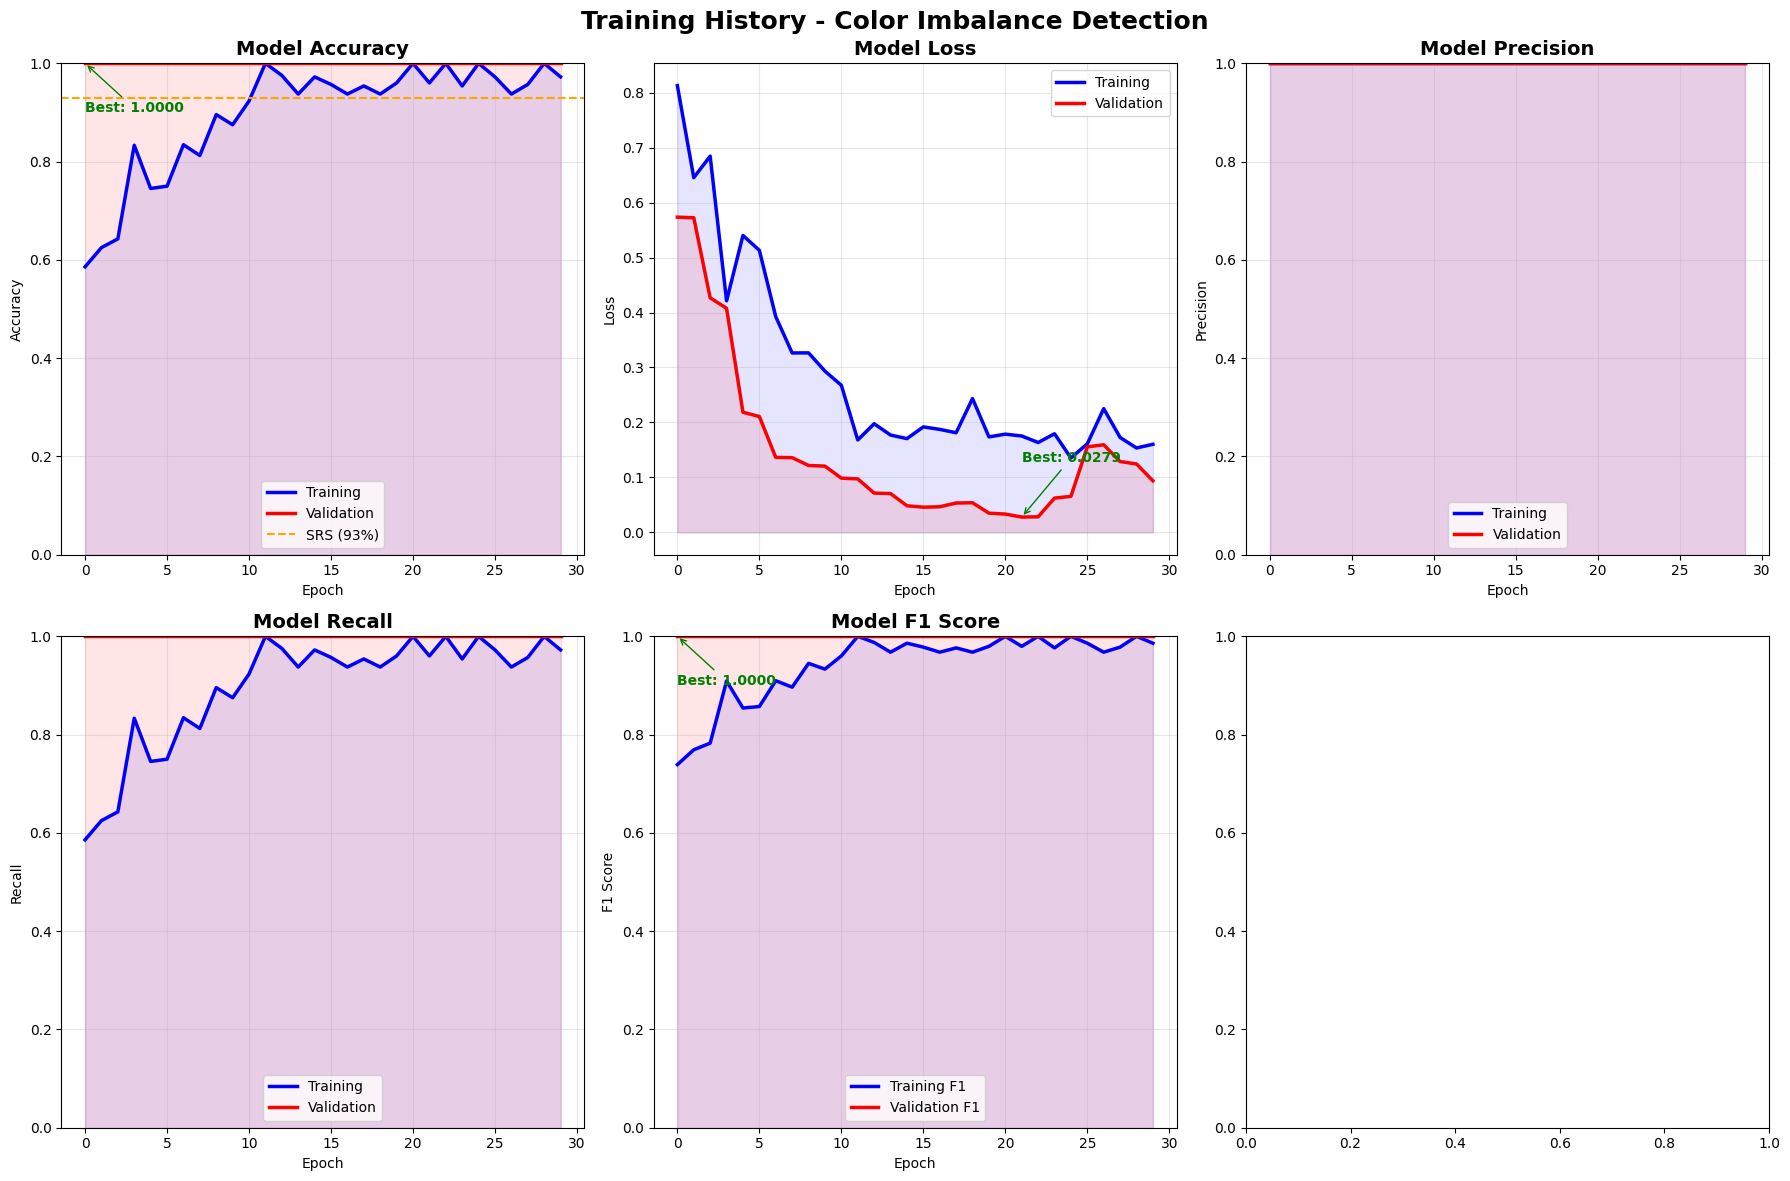

✓ Saved as 'training_history.png'


In [8]:
# STEP 8: Training History Graphs

print("\n[6/10] Generating Training History Graphs...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Training History - Color Imbalance Detection', fontsize=18, fontweight='bold')

# 1. Accuracy
axes[0, 0].plot(history.history['accuracy'], 'b-', label='Training', linewidth=2.5)
axes[0, 0].plot(history.history['val_accuracy'], 'r-', label='Validation', linewidth=2.5)
axes[0, 0].fill_between(range(len(history.history['accuracy'])),
                        history.history['accuracy'], alpha=0.1, color='blue')
axes[0, 0].fill_between(range(len(history.history['val_accuracy'])),
                        history.history['val_accuracy'], alpha=0.1, color='red')
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc)
axes[0, 0].annotate(f'Best: {best_val_acc:.4f}', xy=(best_epoch, best_val_acc),
                    xytext=(best_epoch, best_val_acc-0.1),
                    arrowprops=dict(arrowstyle='->', color='green'),
                    color='green', fontweight='bold')
axes[0, 0].axhline(y=0.93, color='orange', linestyle='--', label='SRS (93%)')
axes[0, 0].legend()

# 2. Loss
axes[0, 1].plot(history.history['loss'], 'b-', label='Training', linewidth=2.5)
axes[0, 1].plot(history.history['val_loss'], 'r-', label='Validation', linewidth=2.5)
axes[0, 1].fill_between(range(len(history.history['loss'])),
                        history.history['loss'], alpha=0.1, color='blue')
axes[0, 1].fill_between(range(len(history.history['val_loss'])),
                        history.history['val_loss'], alpha=0.1, color='red')
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
best_val_loss = min(history.history['val_loss'])
best_epoch_loss = history.history['val_loss'].index(best_val_loss)
axes[0, 1].annotate(f'Best: {best_val_loss:.4f}', xy=(best_epoch_loss, best_val_loss),
                    xytext=(best_epoch_loss, best_val_loss+0.1),
                    arrowprops=dict(arrowstyle='->', color='green'),
                    color='green', fontweight='bold')

# 3. Precision
axes[0, 2].plot(history.history['precision'], 'b-', label='Training', linewidth=2.5)
axes[0, 2].plot(history.history['val_precision'], 'r-', label='Validation', linewidth=2.5)
axes[0, 2].fill_between(range(len(history.history['precision'])),
                        history.history['precision'], alpha=0.1, color='blue')
axes[0, 2].fill_between(range(len(history.history['val_precision'])),
                        history.history['val_precision'], alpha=0.1, color='red')
axes[0, 2].set_title('Model Precision', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_ylim([0, 1])

# 4. Recall
axes[1, 0].plot(history.history['recall'], 'b-', label='Training', linewidth=2.5)
axes[1, 0].plot(history.history['val_recall'], 'r-', label='Validation', linewidth=2.5)
axes[1, 0].fill_between(range(len(history.history['recall'])),
                        history.history['recall'], alpha=0.1, color='blue')
axes[1, 0].fill_between(range(len(history.history['val_recall'])),
                        history.history['val_recall'], alpha=0.1, color='red')
axes[1, 0].set_title('Model Recall', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# 5. F1 Score
train_f1 = [2*(p*r)/(p+r) if (p+r)>0 else 0 for p, r in zip(history.history['precision'], history.history['recall'])]
val_f1 = [2*(p*r)/(p+r) if (p+r)>0 else 0 for p, r in zip(history.history['val_precision'], history.history['val_recall'])]
axes[1, 1].plot(train_f1, 'b-', label='Training F1', linewidth=2.5)
axes[1, 1].plot(val_f1, 'r-', label='Validation F1', linewidth=2.5)
axes[1, 1].fill_between(range(len(train_f1)), train_f1, alpha=0.1, color='blue')
axes[1, 1].fill_between(range(len(val_f1)), val_f1, alpha=0.1, color='red')
axes[1, 1].set_title('Model F1 Score', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 1])
best_val_f1 = max(val_f1)
best_epoch_f1 = val_f1.index(best_val_f1)
axes[1, 1].annotate(f'Best: {best_val_f1:.4f}', xy=(best_epoch_f1, best_val_f1),
                    xytext=(best_epoch_f1, best_val_f1-0.1),
                    arrowprops=dict(arrowstyle='->', color='green'),
                    color='green', fontweight='bold')

# 6. Learning Rate
if 'lr' in history.history:
    axes[1, 2].plot(history.history['lr'], 'g-', linewidth=2.5)
    axes[1, 2].fill_between(range(len(history.history['lr'])),
                            history.history['lr'], alpha=0.2, color='green')
    axes[1, 2].set_yscale('log')
    axes[1, 2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Learning Rate (log)')
    axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved as 'training_history.png'")

Confusion Matrix


[7/10] Generating Confusion Matrix...


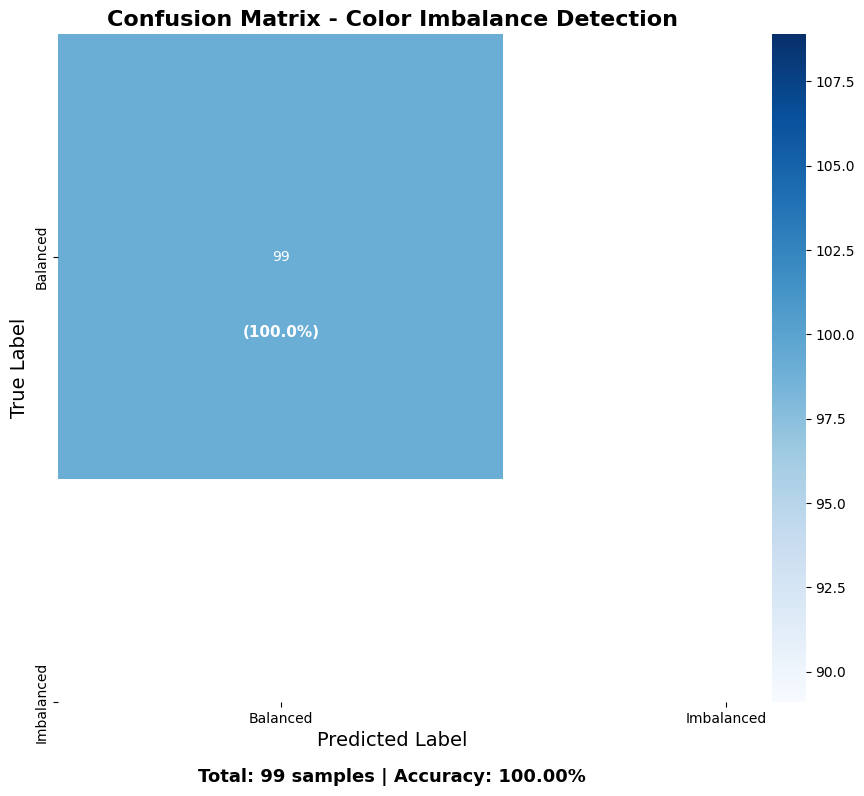

✓ Saved as 'confusion_matrix.png'


In [9]:
# STEP 9: Confusion Matrix

print("\n[7/10] Generating Confusion Matrix...")

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Balanced', 'Imbalanced'],
            yticklabels=['Balanced', 'Imbalanced'],
            cbar=True, ax=ax, square=True)

# Add percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = f'\n({cm_percent[i, j]:.1f}%)'
        ax.text(j+0.5, i+0.65, text, ha='center', va='center',
               color='black' if cm_percent[i, j] < 50 else 'white',
               fontsize=11, fontweight='bold')

ax.set_title('Confusion Matrix - Color Imbalance Detection', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)

total = np.sum(cm)
ax.text(0.5, -0.12, f'Total: {total} samples | Accuracy: {accuracy:.2%}',
        transform=ax.transAxes, ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved as 'confusion_matrix.png'")

Metrics Bar Chart


[10/10] Generating Metrics Bar Chart...


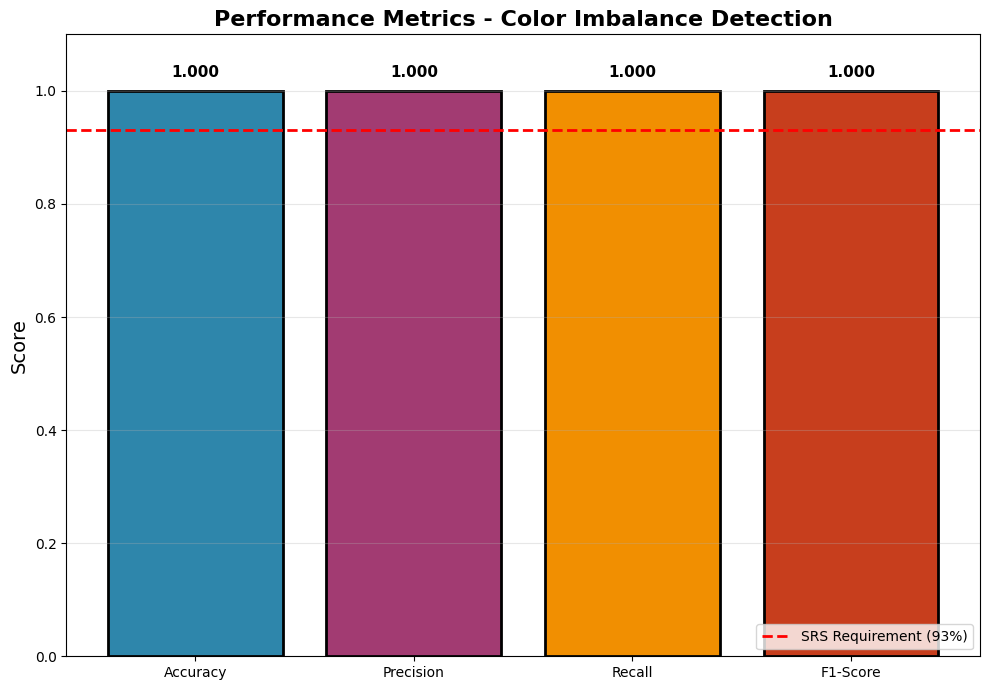

✓ Saved as 'metrics_bar_chart.png'


In [12]:
# STEP 12: Metrics Bar Chart

print("\n[10/10] Generating Metrics Bar Chart...")

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#1B998B']

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.bar(metrics_names, metrics_values, color=colors,
              edgecolor='black', linewidth=2)

for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
           f'{val:.3f}', ha='center', va='bottom',
           fontweight='bold', fontsize=11)

ax.set_ylim([0, 1.1])
ax.set_title('Performance Metrics - Color Imbalance Detection', fontsize=16, fontweight='bold')
ax.set_ylabel('Score', fontsize=14)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=0.93, color='red', linestyle='--', linewidth=2,
           label='SRS Requirement (93%)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved as 'metrics_bar_chart.png'")

Final Summary

In [15]:
# STEP 15: Final Summary

print("\n" + "="*70)
print("TRAINING AND EVALUATION COMPLETE!")
print("="*70)

print("\n📊 Test Results:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"  ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")




TRAINING AND EVALUATION COMPLETE!

📊 Test Results:
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000 (100.00%)
  Recall:    1.0000 (100.00%)
  F1-Score:  1.0000 (100.00%)
  ROC-AUC:   nan (nan%)


Saving Gemini_Generated_Image_9fgjvx9fgjvx9fgj.jpg to Gemini_Generated_Image_9fgjvx9fgjvx9fgj.jpg

Prediction: Imbalanced
Confidence: 92.84%
Score: 0.9284


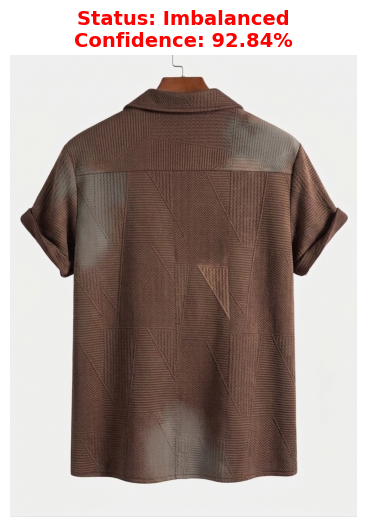

(np.float32(0.92842525), 'Imbalanced')

In [16]:
# QUICK START - Predict new images with one click

# 1. Upload and predict
from google.colab import files

# Load model
model = keras.models.load_model('best_color_imbalance_model.h5')

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Predict
def quick_predict(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_input = np.expand_dims(img_resized.astype(np.float32)/255.0, axis=0)

    pred = model.predict(img_input, verbose=0)[0][0]
    status = 'Imbalanced' if pred > 0.5 else 'Balanced'
    confidence = pred if pred > 0.5 else 1 - pred

    print(f"\nPrediction: {status}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Score: {pred:.4f}")

    # Show result
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    color = 'red' if pred > 0.5 else 'green'
    plt.title(f"Status: {status}\nConfidence: {confidence:.2%}",
              color=color, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    return pred, status

# Run prediction
quick_predict(image_path)